# Data Cleaning — UFO Sightings Dataset

This notebook covers all data cleaning and preparation steps applied to the raw
UFO sightings dataset before exploratory analysis.

**Dataset:** 80,332 records sourced from
[Maven Analytics](https://mavenanalytics.io/data-playground/ufo-sightings)

**Key cleaning steps performed:**
- Missing value handling for `shape`, `comments`, `state`, and `country` columns
- Geographic normalization using reverse geocoding for ~10,000 missing state/country values
- Invalid and legacy state/province code corrections across US, Canada, GB, and Australia
- Outlier detection and removal in `duration (seconds)`
- Latitude and duration column formatting fixes

**Output:** A cleaned dataset (`ufo_clean.csv`) exported to `data/processed/`

> **Note on Re-running this Notebook**
>
> This notebook contains geocoding steps that call an external API to resolve
> ~10,000 missing state and country values. These calls took several hours to
> complete and the results are saved in `data/interim/`.
>
> The final cleaned dataset already exists at `data/processed/ufo_clean.csv`.
> **Do not re-run this notebook unless you need to regenerate the cleaned data
> from scratch.** If you do, you will need to re-run the geocoding scripts in
> `src/` before executing the cells that read the `_mapped.csv` files.

In [ ]:
import sys
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [ ]:
ufo_df = pd.read_csv(ROOT / "data" / "raw" / "ufo_sightings_scrubbed.csv", parse_dates=["datetime"], low_memory=False)

### Chart theme & style for notebook

In [ ]:
from src.plot_config import set_plot_theme

set_plot_theme()

### Initial Inspection (rows, columns, dtypes)

In [ ]:
ufo_df.columns

Index(['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)',
       'duration (hours/min)', 'comments', 'date posted', 'latitude',
       'longitude '],
      dtype='object')

In [ ]:
# removing unwanted spaces in column names
ufo_df.columns = ufo_df.columns.str.strip()

In [ ]:
ufo_df.shape

(80332, 11)

In [ ]:
# Checking for duplicates
ufo_df.duplicated().sum()

np.int64(0)

### Sanity Check - datetime

In [ ]:
ufo_df["datetime"].describe()

count                            80332
mean     2004-05-17 04:07:35.261166336
min                1906-11-11 00:00:00
25%                2001-08-02 21:45:00
50%                2006-11-22 04:05:00
75%                2011-06-21 00:30:00
max                2014-05-08 18:45:00
Name: datetime, dtype: object

### Sanity Check - city

In [ ]:
city = ufo_df["city"]

In [ ]:
city.nunique()

19900

In [ ]:
city.value_counts(dropna=False)

city
seattle                     525
phoenix                     454
portland                    374
las vegas                   368
los angeles                 353
                           ... 
timonium                      1
shicksinny                    1
history channel/illinois      1
rocky boy                     1
troy (east of)                1
Name: count, Length: 19900, dtype: int64

### Handling missing values

In [ ]:
# Total number of NaN values
nan_col_count = dict(ufo_df.isna().sum())

In [ ]:
total_rows = ufo_df.shape[0]

In [ ]:
# missing values in percentage
for k, v in nan_col_count.items():
    print(f"% of NaN in {k}: {round((v / total_rows) * 100, 2)}%; row counts: {v}")

% of NaN in datetime: 0.0%; row counts: 0
% of NaN in city: 0.0%; row counts: 0
% of NaN in state: 7.22%; row counts: 5797
% of NaN in country: 12.04%; row counts: 9670
% of NaN in shape: 2.41%; row counts: 1932
% of NaN in duration (seconds): 0.0%; row counts: 0
% of NaN in duration (hours/min): 0.0%; row counts: 0
% of NaN in comments: 0.02%; row counts: 15
% of NaN in date posted: 0.0%; row counts: 0
% of NaN in latitude: 0.0%; row counts: 0
% of NaN in longitude: 0.0%; row counts: 0


### Handling missing values

Found 4 columns with NaN values. They're state, country, shape, comments
- **Column:** *comments*

    - No of empty rows: 15 (0.02% of total rows)
    - Replaced NaN with "No comment"

- **Column:** *shape*

    - No of empty rows: 1932 (2.41% of total rows)
    - Replaced NaN with "unknown". this will maintain the consistency with the existing "unknown" category.

- **Column:** *state*

    - No of empty rows: 5797 (7.22% of total rows)
  
    - **Germany:** The dataset does not provide any state level information. 

    - **Great Britain:** 
        - There are total of 1905 rows, out of that 1893 already had missing state values. The 12 remaining rows contained non-Great Britain state codes ('wv', 'la', 'bc', 'tn', 'nc', 'ms', 'sk', 'yt', 'nt', 'ri','ns'). 
        - The codes were further investigated using city + lat/long and found out that all 12 rows is located within Great Britain but only the states codes are invalid. 
        - The invalid rows state codes were repalced with "NaN. As a result, all Great Britain rows have state = NaN.

    - **Australia:**
        - There are total of 537 rows, out of that 531 already had missing state values. The 6 remaining rows contained non-Australian state codes (wa (2), sa (2), dc (1), al (1), oh (1)). 
        - The codes were further investigated using city + lat/long and found out that all 6 rows is located within Australian continent but only the states codes are invalid. 
        - The invalid rows state codes were repalced with "NaN. As a result, all Australian rows have state = NaN.

- **Column:** *country*

    - No of empty rows: 9670 (12.04% of total rows)
    - Used Geopy Library to find country name using Longitude and Latitude

In [ ]:
# comment column
print(ufo_df["comments"].isna().sum())
ufo_df["comments"] = ufo_df["comments"].fillna("No comment")

15


In [ ]:
print(ufo_df["comments"].isna().sum())

0


In [ ]:
#shape column
ufo_df["shape"].nunique()

29

In [ ]:
ufo_df["shape"].unique()

array(['cylinder', 'light', 'circle', 'sphere', 'disk', 'fireball',
       'unknown', 'oval', 'other', 'cigar', 'rectangle', 'chevron',
       'triangle', 'formation', nan, 'delta', 'changing', 'egg',
       'diamond', 'flash', 'teardrop', 'cone', 'cross', 'pyramid',
       'round', 'crescent', 'flare', 'hexagon', 'dome', 'changed'],
      dtype=object)

In [ ]:
ufo_df["shape"].value_counts(dropna=False)

shape
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
NaN           1932
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
delta            7
round            2
crescent         2
pyramid          1
flare            1
hexagon          1
dome             1
changed          1
Name: count, dtype: int64

In [ ]:
ufo_df["shape"] = ufo_df["shape"].fillna("unknown")

In [ ]:
ufo_df["shape"].isna().sum()

np.int64(0)

### State & Country Column — Diagnosis

In [ ]:
# state column
state = ufo_df["state"]
state.nunique()

67

In [ ]:
state.unique()

array(['tx', nan, 'hi', 'tn', 'ct', 'al', 'fl', 'ca', 'nc', 'ny', 'ky',
       'mi', 'ma', 'ks', 'sc', 'wa', 'ab', 'co', 'nh', 'wi', 'me', 'ga',
       'pa', 'il', 'ar', 'on', 'mo', 'oh', 'in', 'az', 'mn', 'nv', 'nf',
       'ne', 'or', 'bc', 'ia', 'va', 'id', 'nm', 'nj', 'mb', 'wv', 'ok',
       'ri', 'nb', 'vt', 'la', 'pr', 'ak', 'ms', 'ut', 'md', 'mt', 'sk',
       'wy', 'sd', 'pq', 'ns', 'qc', 'de', 'nd', 'dc', 'nt', 'sa', 'yt',
       'yk', 'pe'], dtype=object)

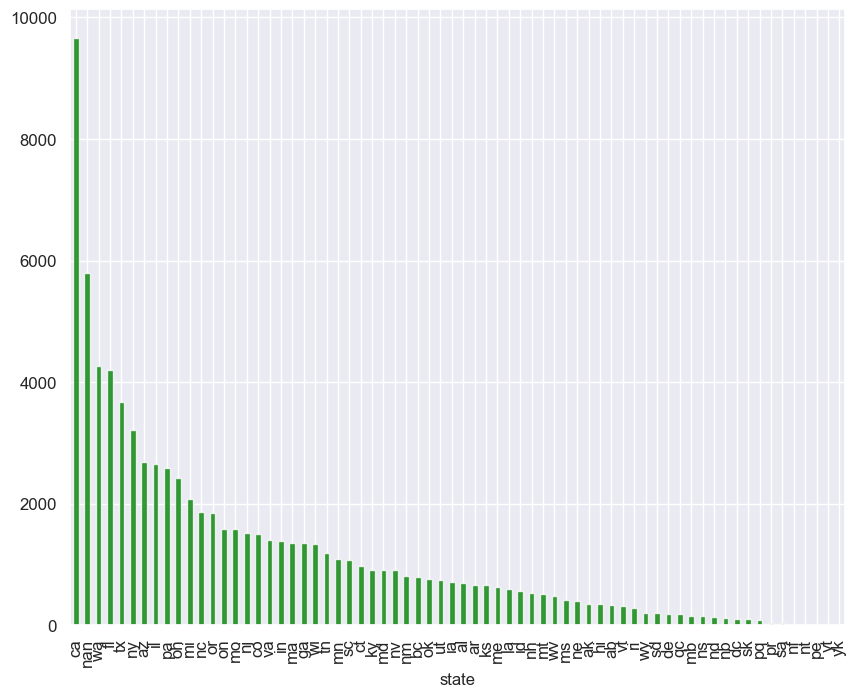

In [ ]:
state.value_counts(dropna=False).plot(kind="bar", figsize=(10, 8), color="green", alpha=0.8)
plt.show()

In [ ]:
# country column
country = ufo_df["country"]
country.nunique()

5

In [ ]:
ufo_df.loc[ufo_df["country"] == "gb", "country"].count()

np.int64(1905)

In [ ]:
ufo_df[country.isin(["de"])]["state"].unique()

array([nan], dtype=object)

In [ ]:
ufo_df[country.isin(["gb"])]["state"].unique()

array([nan, 'wv', 'la', 'bc', 'tn', 'nc', 'ms', 'sk', 'yt', 'nt', 'ri',
       'ns'], dtype=object)

In [ ]:
ufo_df[country.isin(["gb"])]["state"].value_counts(dropna=False)

state
NaN    1893
ns        2
la        1
wv        1
bc        1
tn        1
ms        1
nc        1
sk        1
yt        1
nt        1
ri        1
Name: count, dtype: int64

In [ ]:
gb_state = ['wv', 'la', 'bc', 'tn', 'nc', 'ms', 'sk', 'yt', 'nt', 'ri','ns']

ufo_df[(country == "gb") & (state.isin(gb_state))]

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
10194,2006-11-17 18:25:00,trowbridge (uk/england),wv,gb,circle,600,10minutes,U.F.O.sighting in Wiltshire,2006-12-07,51.318889,-2.208611
12311,2003-11-22 20:50:00,fleetwood (lancashire) (uk/england),la,gb,circle,600,10 minutes,My friends daughter phoned her father to say t...,2003-11-26,53.916667,-3.000000
14588,2013-01-14 02:15:00,bradford (uk/england),bc,gb,circle,86400,week day,((HOAX)) Circle and big.,2013-02-04,51,-3.183333
25070,2006-01-07 06:40:00,lyme regis (uk/england),tn,gb,triangle,600,20-30,an amazing crafts with very bright lights and ...,2006-02-14,50.733333,-2.933333
29791,2009-02-07 19:30:00,morton (near norwich) (uk/england),nc,gb,light,600,10 minutes,Succession of 10-12 silent&#44 glowing orange ...,2009-03-19,51.611667,-2.512500
39729,2007-04-29 22:00:00,lancaster (uk/england).,ms,gb,light,180,3 minutes,ORANGE LIGHT OVER IRISH SEA IN UK. SEEN TO ACC...,2007-06-12,54.066667,-2.833333
42659,2010-05-15 22:30:00,preston (uk/england),sk,gb,fireball,60,1 minute,looked like a plane but was lit up red and the...,2010-06-03,50.783333,-0.466667
46146,2014-05-07 11:56:00,heswall (uk/england),yt,gb,triangle,40,40 seconds,((HOAX??)) Long triangle object moves with sp...,2014-05-08,53.316667,-3.100000
47225,1978-06-01 06:30:00,felixstowe (uk/england),nt,gb,sphere,900,15 min,jUST TO MAKE SURE PLEASE DO NOT INCLUDE MY NA...,2008-06-12,51.966667,1.350000
67792,2009-08-19 22:00:00,leeds (uk/england),ri,gb,unknown,120,2 minutes,controlled and deliberate manouvers,2009-08-27,53.8,-1.583333


In [ ]:
ufo_df.loc[state.isin(gb_state), "state"] = np.nan

In [ ]:
country.value_counts(dropna=False)

country
us     65114
NaN     9670
ca      3000
gb      1905
au       538
de       105
Name: count, dtype: int64

There are five countries in this dataset
- USA (us)
- Canada (ca)
- Great Britain (gb)
- Australia (au)
- Germany (de)

Majority is from US and second majority is NaN. 

In [ ]:
# Working on country = "au"
ufo_df[ufo_df["country"] == "au"]["state"].value_counts(dropna=False)

state
NaN    531
wa       2
sa       2
dc       1
al       1
oh       1
Name: count, dtype: int64

In [ ]:
# Replaced all state values with NaN for country = au
ufo_df.loc[(country == "au") & (state.isin(["wa",  "sa", "dc", "al", "oh"])), "state"] = np.nan

In [ ]:
us_ca_codes = {
  "us": { "al", "ak", "az", "ar", "ca", "co", "ct", "dc", "de", "fl",
          "ga", "hi", "ia", "id", "il", "in", "ks", "ky", "la", "ma",
          "md", "me", "mi", "mn", "mo", "ms", "mt", "nc", "nd", "ne",
          "nh", "nj", "nm", "nv", "ny", "oh", "ok", "or", "pa", "ri",
          "sc", "sd", "tn", "tx", "ut", "va", "vt", "wa", "wi", "wv",
          "wy", "pr" },

  "ca": { "ab", "bc", "mb", "nb", "nl", "nt", "ns", "nu", "on", "pe",
          "qc", "sk", "yt" }
}

In [ ]:
ufo_df[ufo_df["country"] == "ca"]["country"].count()

np.int64(3000)

In [ ]:
#  Working on country = "ca"
ufo_df[ufo_df["country"] == "ca"]["state"].value_counts(dropna=False)

state
on     1354
NaN     903
ab      288
mb      127
qc      124
nb       86
pq       64
sa       27
nf       15
pe       10
yk        2
Name: count, dtype: int64

In [ ]:
#  Checking for invalid states codes for county == "ca"
mask = (country == "ca") & (~state.isin(us_ca_codes["ca"]) & (~state.isna()))
ufo_df[mask]["state"].value_counts()

state
pq    64
sa    27
nf    15
yk     2
Name: count, dtype: int64

**Canada — State Code Corrections**

- **yk** → ***yt*** (Yukon)
    Likely a typo; corrected to the official code *yt*.

- **nf** → ***nl*** (Newfoundland and Labrador)
    nf was the old Canada Post abbreviation before 2001; updated to *nl*.

- **sa** → ***sk*** (Saskatchewan)
    sa is not a valid Canadian code. Based on the Canada geography and the fact that “Saskatoon” is the largest city in Saskatchewan (Canada), the code was corrected to *sk*.

- **pq** → ***qc*** (Québec)
    pq was the old abbreviation for Québec; updated to *qc*.


In [ ]:
ufo_df.loc[(mask) & (state == "yk"), "state"] = "yt"
ufo_df.loc[(mask) & (state == "nf"), "state"] = "nl"
ufo_df.loc[(mask) & (state == "sa"), "state"] = "sk"
ufo_df.loc[(mask) & (state == "pq"), "state"] = "qc"

In [ ]:
# futher investigating missing values in state code for country == "ca"
ca_mask = (country == "ca") &  (state.isna())
ufo_df.loc[ca_mask].info()

<class 'pandas.core.frame.DataFrame'>
Index: 903 entries, 95 to 80295
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              903 non-null    datetime64[ns]
 1   city                  903 non-null    object        
 2   state                 0 non-null      object        
 3   country               903 non-null    object        
 4   shape                 903 non-null    object        
 5   duration (seconds)    903 non-null    object        
 6   duration (hours/min)  903 non-null    object        
 7   comments              903 non-null    object        
 8   date posted           903 non-null    object        
 9   latitude              903 non-null    object        
 10  longitude             903 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 84.7+ KB


In [ ]:
ufo_df.loc[ca_mask].drop_duplicates().to_csv(ROOT / "data" / "interim" / "canada_nan_cities_mapped.csv", index=True)

In [ ]:
province_to_code = {
    "British Columbia": "bc",
    "Nova Scotia": "ns",
    "Saskatchewan": "sk",
    "Prince Edward Island": "pe",
    "Ontario": "on",
    "Quebec": "qc",
    "Manitoba": "mb",
    "Northwest Territories": "nt",
    "Nunavut": "nu",
    "Yukon": "yt",
    "New Brunswick": "nb",
}

The exported CSV was mapped to province codes using the `province_to_code` dictionary.
Results are loaded back and merged with the main dataframe by index.

In [96]:
ca_state_map_df = pd.read_csv(
    ROOT / "data" / "interim" / "canada_nan_cities_mapped.csv", 
    usecols=["Unnamed: 0", "results_state"], 
    index_col=["Unnamed: 0"]
    )

ValueError: Usecols do not match columns, columns expected but not found: ['results_state']

In [ ]:
ca_state_map_df.head()

,results_state
Unnamed: 0,
114,Prince Edward Island
576,Prince Edward Island
919,Saskatchewan
1096,Prince Edward Island
2510,Prince Edward Island


In [ ]:
ca_state_map_df["state"] = ca_state_map_df["results_state"].map(province_to_code)

In [ ]:
ca_state_map_df.tail()

,results_state,state
Unnamed: 0,,
79767,British Columbia,bc
80078,British Columbia,bc
80079,British Columbia,bc
80183,British Columbia,bc
80295,Nova Scotia,ns


Merging the mapped province codes back into the main dataframe using index alignment.

For the 654 remaining Canadian rows with no state, a reverse geocoding script (`src/get_ca_cities.py`) was used to look up the province from latitude/longitude. Results were saved to `canada_nan_remaining_mapped.csv` and merged back by index.

In [ ]:
ufo_df["state"] = ufo_df["state"].fillna(ca_state_map_df["state"])

In [ ]:
ca_nan_remain = ufo_df[ca_mask].loc[ufo_df["state"].isna()]

In [ ]:
ca_nan_remain.to_csv(ROOT / "data" / "interim" / "canada_nan_remaining_mapped.csv", index=True)

In [ ]:
ca_nan_remain_df = pd.read_csv(
    ROOT / "data" / "interim" / "canada_nan_remaining_mapped.csv",
    usecols=["Unnamed: 0", "results_state"],
    index_col=["Unnamed: 0"]
)

In [ ]:
ca_nan_remain_df["state"] = ca_nan_remain_df["results_state"].map(province_to_code)

In [ ]:
ca_nan_remain_df.head()

In [ ]:
ufo_df["state"] = ufo_df["state"].fillna(ca_nan_remain_df["state"])

In [ ]:
ufo_df.isna().sum()

### Handling Missing US State Values

In [ ]:
us_mask = (ufo_df["country"] == "us") & (ufo_df["state"].isna())

In [ ]:
ufo_df[us_mask].shape

In [ ]:
ufo_df.loc[us_mask].drop_duplicates().to_csv(ROOT / "data" / "interim" / "canada_nan_remaining_mapped.csv", index=True)

There ar 4468 rows with column value us and country nan

In [ ]:
us_state_abbrev = {
    "Alabama": "al",
    "Alaska": "ak",
    "Arizona": "az",
    "Arkansas": "ar",
    "California": "ca",
    "Colorado": "co",
    "Connecticut": "ct",
    "Delaware": "de",
    "Florida": "fl",
    "Georgia": "ga",
    "Hawaii": "hi",
    "Idaho": "id",
    "Illinois": "il",
    "Indiana": "in",
    "Iowa": "ia",
    "Kansas": "ks",
    "Kentucky": "ky",
    "Louisiana": "la",
    "Maine": "me",
    "Maryland": "md",
    "Massachusetts": "ma",
    "Michigan": "mi",
    "Minnesota": "mn",
    "Mississippi": "ms",
    "Missouri": "mo",
    "Montana": "mt",
    "Nebraska": "ne",
    "Nevada": "nv",
    "New Hampshire": "nh",
    "New Jersey": "nj",
    "New Mexico": "nm",
    "New York": "ny",
    "North Carolina": "nc",
    "North Dakota": "nd",
    "Ohio": "oh",
    "Oklahoma": "ok",
    "Oregon": "or",
    "Pennsylvania": "pa",
    "Rhode Island": "ri",
    "South Carolina": "sc",
    "South Dakota": "sd",
    "Tennessee": "tn",
    "Texas": "tx",
    "Utah": "ut",
    "Vermont": "vt",
    "Virginia": "va",
    "Washington": "wa",
    "West Virginia": "wv",
    "Wisconsin": "wi",
    "Wyoming": "wy"
}


In [ ]:
usa_state_map_df = pd.read_csv(
    ROOT / "data" / "interim" / "usa_nan_cities_mapped.csv", 
    usecols=["Unnamed: 0", "results_state"], 
    index_col=["Unnamed: 0"]
    )

In [ ]:
usa_state_map_df.head()

In [ ]:
usa_state_map_df["state"] = usa_state_map_df["results_state"].map(us_state_abbrev)

In [ ]:
usa_state_map_df.tail()

In [ ]:
ufo_df["state"] = ufo_df["state"].fillna(usa_state_map_df["state"])

In [ ]:
ufo_df[us_mask].head()

### Validation — State & Country Completeness

In [ ]:
ufo_df.loc[(ufo_df["country"].isin(["us", "ca"])) & (ufo_df["state"].isna()), "country"].value_counts()

Checking Individually for each countries and if here is any nan in their state column. For au, de, db will be having nan values. But for ca it should be zero and in the us there may be some missing values

In [ ]:
ufo_df.loc[(ufo_df["state"].isna()) & (ufo_df["country"].isin(["ca", "us"])), ["state", "country"]].value_counts()

In [ ]:
ufo_df.loc[(ufo_df["state"].isna()), ["country"]].value_counts()

Check for rows that has nan in country column and values in state columns

In [ ]:
ufo_df.loc[ufo_df["country"].isna()].info()

There are 9670 rows in the column "country" has NaN value.

1. find the rows that has values in state columns but country is missing

In [ ]:
ufo_df.loc[(ufo_df["country"].isna()) & ~(ufo_df["state"].isna()), "state"].count()

There are 5872 rows with values in state but missing values in country columns. 
- Need to check whether these values are states in us and canada. 
- If these values are not in us and ca, then investigate those rows.
- If these values are of us and ca then map these using the us_ca_codes

In [ ]:
nan_country_mask = (ufo_df["country"].isna()) & ~(ufo_df["state"].isna())
ufo_df[nan_country_mask].head()

In [ ]:
list(ufo_df[nan_country_mask]["state"].unique())

Checked whether us and ca share any same state abbreviation and found out they dont. so i combined both country's state abbreviation to check whether any other code is there because of typo or other mistake and found out there isnt.

In [ ]:
us_ca_list = list(us_ca_codes["us"]) + list(us_ca_codes["ca"])

In [ ]:
for val in list(ufo_df[nan_country_mask]["state"].unique()):
    if val not in us_ca_list:
        print(val)

Mapping the state to their respective countries

In [ ]:
def get_country_from_state(state):
    if pd.isna(state):
        return None
    
    if state in us_ca_codes["us"]:
        return "us"
    elif state in us_ca_codes["ca"]:
        return "ca"
    else:
        return None

In [ ]:
ufo_df["country"] = ufo_df["state"].apply(get_country_from_state)

In [ ]:
ufo_df[nan_country_mask].count()

### Handling Rows with No Country or State

In [ ]:
ufo_df.loc[(ufo_df["country"].isna()) & (ufo_df["state"].isna())].count()

There are 6346 countries with missing values in both state and country columns.

Using the python script that extract value based on longtitude and latitude, will get the values for each country. 

- if the country is any of the 5 countries from the dataset (us, ca, au, gb. de) -> the value will be that itself. if the value is us or ca then the state value will be also extracted. 

- if the county is not from 5 countries list then the value will be row (rest of world).



In [ ]:
ufo_df.loc[(ufo_df["country"].isna()) & (ufo_df["state"].isna())].to_csv(ROOT / "data" / "interim" / "country_nan.csv", index=True)

In [ ]:
country_nan_df = pd.read_csv(
    ROOT / "data" / "interim" / "country_nan_mapped.csv", 
    usecols=["Unnamed: 0", "results_state", "results_country"],
    index_col="Unnamed: 0"
    )

In [ ]:
country_nan_df.tail()

In [ ]:
ufo_df["country"] = ufo_df["country"].fillna(country_nan_df["results_country"])

In [ ]:
ufo_df.loc[(ufo_df["country"].isna()) | (ufo_df["state"].isna())].count()

In [ ]:
ufo_df["state"] = ufo_df["state"].fillna(country_nan_df["results_state"])

In [ ]:
ufo_df.info()

### Final Validation — NaN State Count


Find the sum of each countries au, gb, de, row -- the sum of these values should be the sum of total nan value in the dataset.

In [ ]:
ufo_df["state"].isna().sum()

In [ ]:
ufo_df.loc[ufo_df["country"].isin(["gb", "au", "de", "row"]), "state"].isna().sum()

### Data Audit — Anomalous Values

### Data Audit - Column: duration (seconds)
- Found 3 values with backticks (\`2\`, \`8\`, \`0.5\`).
- Applied cleaning: removed backticks, stripped whitespace
- Rows affected: 3


In [ ]:
ufo_df["duration (seconds)"].isna().sum()

In [ ]:
ufo_df["duration_(seconds)_cleaned"] = pd.to_numeric(ufo_df['duration (seconds)'], errors="coerce")

In [ ]:
ufo_df["duration_(seconds)_cleaned"].isna().sum()

In [ ]:
coerced_count = (
    ufo_df["duration_(seconds)_cleaned"].isna().sum()
    - ufo_df["duration (seconds)"].isna().sum()
)

print(f"Values coerced to NaN: {coerced_count}")

In [ ]:
mask = ufo_df["duration_(seconds)_cleaned"].isna() & ~ufo_df["duration (seconds)"].isna()

ufo_df.loc[mask, :]

In [ ]:
ufo_df.drop(columns="duration_(seconds)_cleaned", inplace=True)

In [ ]:
# Clean "duration (seconds)" column
ufo_df["duration (seconds)"] = (
    ufo_df["duration (seconds)"]
    .astype(str)
    .str.replace("`", "")
    .str.strip()
)

ufo_df["duration (seconds)"] = pd.to_numeric(ufo_df["duration (seconds)"], errors="coerce")
ufo_df.info()


Summary stats before cleaning the "duration (seconds) column"

In [ ]:
print(ufo_df["duration (seconds)"].describe().to_string(float_format="{:.2f}".format))

- The dataset contains extreme outliers, which heavily skews the data. 
- The standard deviation is 620216.79 (i.e ≈ 7 days) showing that the data has extreme variability due to outliers. 
- The min value is 0 seconds, which is likely due to bad data entry that requires further investigation. 
- The max value is 97836000.00 (≈ 3 years!). Clearly a data entry error.
- Duration percentiles:

  - 25% of sightings lasted <= 30 seconds.
  - 50% of sightings lasted <= 180 seconds (3 minutes)
  - 75% of sightings lasted <= 600 seconds (10 minutes)
  
  These obversations clearly shows that most sightings are short (30 secs - 10 mins).
- Overall, the data is highly skewed and the outliers are needed to be dealt with before any further analysis. 

In [ ]:
plt.title("Boxplot of UFO Sighting Durations (in seconds) (Highly Skewed Data)")
sns.boxplot(data=ufo_df, y="duration (seconds)")
plt.show()

In [ ]:
plt.title("Histogram of UFO Sighting Durations (in seconds) (Highly Skewed Data)")
sns.histplot(ufo_df["duration (seconds)"], bins=100, log_scale=(True, False))
plt.xlabel("duration (seconds, log scale)")
plt.show()

### Outlier Handling — Duration Column

Investigating and cleaning 0-second durations

In [ ]:
ufo_df.loc[ufo_df["duration (seconds)"] < 1]

In [ ]:
sns.histplot(ufo_df.loc[ufo_df["duration (seconds)"] < 1, "duration (seconds)"], bins=20)
plt.title("Distribution of UFO Sightings ≤ 1 Second (n=93)")
plt.show()

There are 93 sightings with reported durations of ≤ 1 second. Such short durations are likely unrealistic or the result of data entry noise. Therefore, these rows were dropped from the dataset to improve data quality.

In [ ]:
ufo_df.drop(ufo_df[ufo_df["duration (seconds)"] < 1].index, inplace=True)

In [ ]:
ufo_df.info()

Investigating and cleaning unrealistic max values

In [ ]:
ufo_df.loc[ufo_df["duration (seconds)"] > 600] \
.sort_values(by="duration (seconds)", ascending=False).count()

A log-spaced binned histogram for the entire dataset that shows how spread out the data is in the "duration (seconds)" column. 

In [ ]:
s = ufo_df["duration (seconds)"]

bins = np.logspace(
    np.log10(s[s>0].min()), 
    np.log10(s.quantile(0.999)), 
    60
    )

In [ ]:
sns.histplot(s[s>0], bins=bins, edgecolor="black", linewidth=0.5)
plt.xscale("log")
plt.xlabel("Duration (seconds, log scale)")
plt.ylabel("Count")
plt.title("Distribution of UFO sighting durations (log scale)")
plt.show()

- X-axis (Duration, log scale):
    - 10<sup>2</sup> = 1000 seconds ≈ 16 minutes
    - 10<sup>3</sup> = 10,000 seconds ≈ 2.7 hours
    - 10<sup>4</sup> = 100,000 seconds ≈ 27 hours (~1 day)
    - 10<sup>5</sup> = 1,000,000 seconds ≈ 11.6 days
- Y-axis (count):
    How many sightings fall into each bin

In [ ]:
s_long = ufo_df[ufo_df["duration (seconds)"] > 600]["duration (seconds)"]

# create log-spaced bins
bins_long = np.logspace(
    np.log10(s_long.min()),
    np.log10(s_long.quantile(0.999)),  # cut off extreme outliers
    50
)

In [ ]:
sns.histplot(s_long, bins=bins_long, edgecolor="black", linewidth=0.5)
plt.xscale("log")
plt.xlabel("Duration (seconds, log scale)")
plt.ylabel("Count")
plt.title("Distribution of UFO sightings > 600 seconds (log scale)")
plt.show()

- 600 seconds (10 minutes) was the cutoff used to define "long sightings".
- A total of 18341 values are above 600s. 
- The majority of the cluster fall between 15 - 30 minutes in the long sightings category. 
- A small number of extreme outliers extend into days or even weeks, which are likely due to overestimation or data entry errors.”

In [ ]:
bins = [600, 1800, 3600, 10800, 21600, 43200, 86400, 604800, float("inf")]
labels = [
    "10–30 min",
    "30–60 min",
    "1–3 hr",
    "3–6 hr",
    "6–12 hr",
    "12–24 hr",
    "1–7 days",
    ">7 days"
]

In [ ]:
s_long_binned = pd.cut(s_long, bins=bins, labels=labels, right=False)

In [ ]:
counts = s_long_binned.value_counts().sort_index()
percentages = (counts / len(s_long) * 100).round(2)

summary = pd.DataFrame({"Count": counts, "Percentage": percentages})
summary

In [ ]:
sns.barplot(summary, x="duration (seconds)", y="Count", alpha=0.8)
plt.xticks(rotation=45)
plt.title("Distribution of Long-Duration UFO Sightings (>10 Minutes)")
plt.xlabel("Duration Category")
plt.show()

Out of 18,341 long-duration sightings (>10 minutes), only 217 (~1.2%) lasted longer than 24 hours.

Relative to the full dataset (80322 rows), this represents just ~0.3% of the reported sightings. Because of the negligible proportion and how much these values are skewing the distribution, these rows were dropped for further analysis.

In [ ]:
ufo_df.drop(ufo_df[ufo_df["duration (seconds)"] >= 86400].index, inplace=True)

In [ ]:
ufo_df["duration (seconds)"].describe()

In [ ]:
sns.histplot(ufo_df["duration (seconds)"], bins=500, linewidth=0.5)
plt.title("Distribution of UFO sighting durations (log scale) - After cleaning")
plt.xscale("log")
plt.show()

- After cleaning multi-day and multi-year outliers are gone. 
- Distribution focuses on plausible values.
- Most UFO sightings are short. These clusters are between a few seconds and few minutes. 
- Very long sightings exists but are much rarer. 

Summary stats after cleaning

In [ ]:
print(ufo_df["duration (seconds)"].describe().to_string(float_format="{:.2f}".format))

In [ ]:
ufo_df["duration (seconds)"].describe(percentiles=[.25, .5, .75, .9, .95, .99])

### Sanity Check - Longitude

Checked the minimum and maximum values for longitude and confirmed that values are within the valid range -180 to 180.


In [ ]:
ufo_df["longitude"].describe()

### Data Audit - Column: latitude              
- Found 1 invalid entry: "33q.200088"
    Cross checked the latitude using the longtiude (-105.624152), city (Mescalero Indian Reservation), and state (NM) and confirmed that the correct latitude for this region is ≈ 33.2°N, indicating that the "q" is a typo. 
- Applied cleaning: removed "q" character
- Rows affected: 1


In [ ]:
ufo_df["latitude"].isna().sum()


In [ ]:
ufo_df["latitude_cleaned"] = pd.to_numeric(ufo_df["latitude"], errors="coerce")

In [ ]:
ufo_df["latitude_cleaned"].isna().sum()

In [ ]:
coerced_count = (
    ufo_df["latitude_cleaned"].isna().sum()
    - ufo_df["latitude"].isna().sum()
)

print(f"Values coerced to NaN: {coerced_count}")

In [ ]:
lat_mask = ~ufo_df["latitude"].isna() & ufo_df["latitude_cleaned"].isna()

ufo_df[lat_mask]

In [ ]:
ufo_df.drop(columns="latitude_cleaned", inplace=True) 

In [ ]:
# Clean "latitude" column
ufo_df["latitude"] = (
    ufo_df["latitude"]
    .astype(str)
    .str.replace("q", "")
    .str.strip()
)

ufo_df["latitude"] = pd.to_numeric(ufo_df['latitude'], errors="coerce")
ufo_df.info()

In [ ]:
ufo_df.head()

Saving the cleaned dataset into a .csv file 

In [ ]:
ufo_df.to_csv(
    ROOT / "data" / "processed" / "ufo_clean.csv", 
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
    encoding="utf-8"
    )

## Cleaning Complete

All major data quality issues have been resolved. The final dataset contains
**80,022 rows** after removing 310 records with unrealistic durations.

**Summary of changes made:**
- `shape`: 1,932 NaN values filled with `"unknown"`
- `comments`: 15 NaN values filled with `"No comment"`
- `state`: ~10,000 missing values resolved via code correction and reverse geocoding
- `country`: ~9,670 missing values resolved via state-code mapping and reverse geocoding
- `duration (seconds)`: 93 sub-1-second rows dropped; 217 rows exceeding 24 hours dropped
- `latitude`: 1 invalid entry (`"33q.200088"`) corrected to `33.2`

The cleaned dataset has been exported to `data/processed/ufo_clean.csv`.